<a href="https://colab.research.google.com/github/KanisettiVanitha/DataScience-MachineLearning/blob/main/SpotifyListeningHistoryProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Load dataset

In [4]:
df = pd.read_csv("/content/drive/MyDrive/spotify_history.csv")

# Understanding the data

In [7]:
df.head(3)    #first 5 rows of data


,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
0,2J3n32GeLmMjwuAzyhcSNe,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False
1,1oHxIPqJyvAYHy0PVrDU98,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False
2,487OPlneJNni3NWC8SYqhW,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False


In [8]:
df.tail(3)    #last 5 rows of data

,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
149857,0HHdujGjOZChTrl8lJWEIq,2024-12-15 23:06:22,android,1283,"Stop This Train - Live at the Nokia Theatre, L...",John Mayer,Where the Light Is: John Mayer Live In Los Ang...,fwdbtn,fwdbtn,True,True
149858,7peh6LUcdNPcMdrSH4JPsM,2024-12-15 23:06:23,android,1306,I Don't Trust Myself (With Loving You),John Mayer,Continuum,fwdbtn,fwdbtn,True,True
149859,6iGU74CwXuT4XVepjc9Emf,2024-12-15 23:06:25,android,1893,God Only Knows - Mono,The Beach Boys,Pet Sounds,fwdbtn,fwdbtn,True,True


In [9]:
df.shape      #knowing total rows and columns of dataset

(149860, 11)

In [10]:
df.columns    #get all column names in dataset

Index(['spotify_track_uri', 'ts', 'platform', 'ms_played', 'track_name',
       'artist_name', 'album_name', 'reason_start', 'reason_end', 'shuffle',
       'skipped'],
      dtype='object')

In [11]:
df.info()     #getting dataset informatio such as column_name-not_null count-dtype of column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   spotify_track_uri  149860 non-null  object
 1   ts                 149860 non-null  object
 2   platform           149860 non-null  object
 3   ms_played          149860 non-null  int64 
 4   track_name         149860 non-null  object
 5   artist_name        149860 non-null  object
 6   album_name         149860 non-null  object
 7   reason_start       149717 non-null  object
 8   reason_end         149743 non-null  object
 9   shuffle            149860 non-null  bool  
 10  skipped            149860 non-null  bool  
dtypes: bool(2), int64(1), object(8)
memory usage: 10.6+ MB


In [12]:
df.dtypes     #datatype of each column

,0
spotify_track_uri,object
ts,object
platform,object
ms_played,int64
track_name,object
artist_name,object
album_name,object
reason_start,object
reason_end,object
shuffle,bool


In [14]:
df.describe()

,ms_played
count,1.498600e+05
mean,1.283166e+05
std,1.178401e+05
min,0.000000e+00
25%,2.795000e+03
50%,1.388400e+05
75%,2.185070e+05
max,1.561125e+06


# cleaning data

In [ ]:
df.isnull().sum()   #finding null values

,0
spotify_track_uri,0
ts,0
platform,0
ms_played,0
track_name,0
artist_name,0
album_name,0
reason_start,143
reason_end,117
shuffle,0


In [ ]:
df.duplicated().sum()    #finding duplicate values

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)     #droping duplicates

np.int64(0)

# analysing the statistical measures of listening duration

In [ ]:
df["ms_played"].describe()

,ms_played
count,1.486750e+05
mean,1.280607e+05
std,1.178178e+05
min,0.000000e+00
25%,2.786000e+03
50%,1.383860e+05
75%,2.183330e+05
max,1.561125e+06


# converting millisec to min of time_duration

In [ ]:
# milliseconds to minutes
df["minutes_played"] = df["ms_played"] / 60000

In [ ]:
df["minutes_played"].describe()

,minutes_played
count,148675.000000
mean,2.134345
std,1.963629
min,0.000000
25%,0.046433
50%,2.306433
75%,3.638883
max,26.018750


# analysing total duration of dataset

In [ ]:
total_minutes = df["minutes_played"].sum()

print("Total listening time:", total_minutes, "minutes")
print("Total listening time:", total_minutes / 60, "hours")

Total listening time: 317323.6903333332 minutes
Total listening time: 5288.728172222221 hours


# data of tracks which have played >1200000ms

In [15]:
df[df["ms_played"] > 1200000].head()

,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
17995,0Ja8Eig8cisoXDUKnZK6kD,2017-06-20 10:20:46,android,1319375,Nothing Left To Say / Rocks - Medley,Imagine Dragons,Night Visions,trackdone,trackdone,True,False
94634,7ERSQrRptZVM7q3VOdM7OL,2021-03-04 00:27:48,android,1561125,Tubular Bells - Pt. I,Mike Oldfield,Tubular Bells,appload,trackdone,False,False
94635,5GmNpR6bCLGk2tdUTFfNJM,2021-03-04 00:51:05,android,1397146,Tubular Bells - Pt. II,Mike Oldfield,Tubular Bells,trackdone,trackdone,False,False
129895,4n1ZGm3TxYmoYe1YR8cMus,2023-01-28 20:20:38,android,1209343,Desolation Row,Bob Dylan,Highway 61 Revisited,trackdone,unknown,True,False


#Which records have the highest playback duration?

In [ ]:
df.sort_values("ms_played", ascending=False).head()


,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
94634,7ERSQrRptZVM7q3VOdM7OL,2021-03-04 00:27:48,android,1561125,Tubular Bells - Pt. I,Mike Oldfield,Tubular Bells,appload,trackdone,False,False
94635,5GmNpR6bCLGk2tdUTFfNJM,2021-03-04 00:51:05,android,1397146,Tubular Bells - Pt. II,Mike Oldfield,Tubular Bells,trackdone,trackdone,False,False
17995,0Ja8Eig8cisoXDUKnZK6kD,2017-06-20 10:20:46,android,1319375,Nothing Left To Say / Rocks - Medley,Imagine Dragons,Night Visions,trackdone,trackdone,True,False
129895,4n1ZGm3TxYmoYe1YR8cMus,2023-01-28 20:20:38,android,1209343,Desolation Row,Bob Dylan,Highway 61 Revisited,trackdone,unknown,True,False
146949,3YB9cvd668HXBEq8rbBW8P,2024-09-28 19:50:22,android,1142390,Human Sadness,The Voidz,Tyranny,trackdone,endplay,True,True


In [ ]:
df["platform"].unique()

array(['web player', 'windows', 'android', 'iOS', 'cast to device', 'mac'],
      dtype=object)

In [ ]:
df["platform"].nunique()

6

#Which artists have the most listening activity?

In [ ]:
df.groupby("artist_name").count()


,spotify_track_uri,ts,platform,ms_played,track_name,album_name,reason_start,reason_end,shuffle,skipped
artist_name,,,,,,,,,,
"""Weird Al"" Yankovic",2,2,2,2,2,2,2,2,2,2
& Friends,1,1,1,1,1,1,0,0,1,1
*NSYNC,2,2,2,2,2,2,2,2,2,2
.Sinh,1,1,1,1,1,1,1,1,1,1
070 Shake,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...
Örjan Hultén Orion,2,2,2,2,2,2,2,2,2,2
ゼロ戦,6,6,6,6,6,6,6,6,6,6
岸正之,2,2,2,2,2,2,2,2,2,2


In [ ]:
df["artist_name"].value_counts().head(10)
# same as for above code this is clean way

,count
artist_name,
The Beatles,13530
The Killers,6748
John Mayer,4797
Bob Dylan,3790
Paul McCartney,2685
Led Zeppelin,2470
Johnny Cash,2467
The Rolling Stones,2367
Radiohead,2295


 # which platform is used most

In [ ]:
df["platform"].value_counts()


,count
platform,
android,139562
iOS,3049
cast to device,3015
windows,1691
mac,1176
web player,182


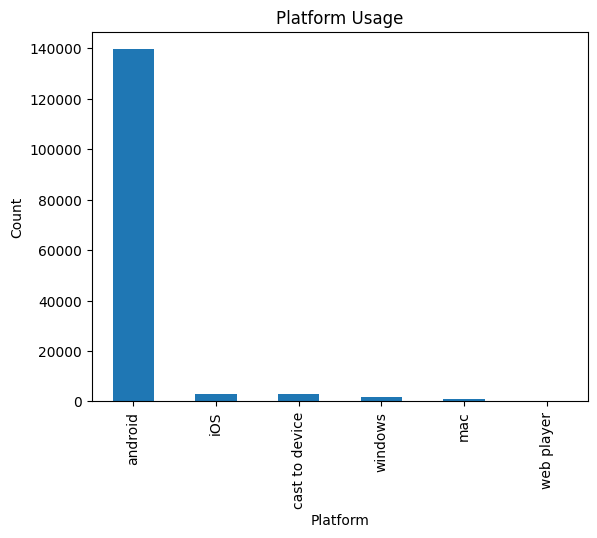

In [ ]:
df["platform"].value_counts().plot(kind="bar")

plt.title("Platform Usage")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.show()

# Analyze skipped songs

In [ ]:
df["skipped"].value_counts()


,count
skipped,
False,140807
True,7868


In [ ]:
df["skipped"].value_counts(normalize=True) * 100

,proportion
skipped,
False,94.70792
True,5.29208


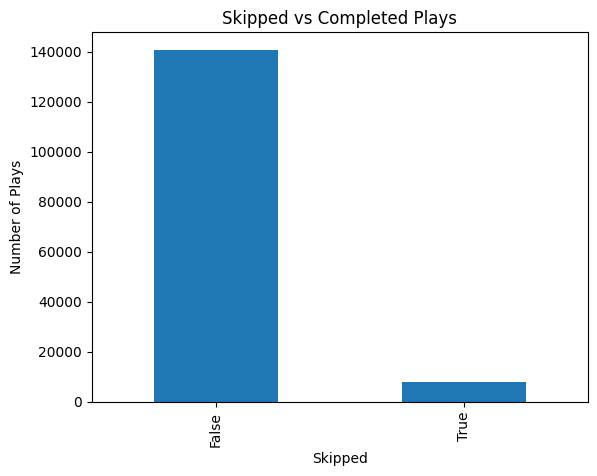

In [ ]:
df["skipped"].value_counts().plot(kind="bar")

plt.title("Skipped vs Completed Plays")
plt.xlabel("Skipped")
plt.ylabel("Number of Plays")
plt.show()

#Analysing shuffle behaviour

In [ ]:

df["shuffle"].value_counts()

,count
shuffle,
True,111516
False,37159


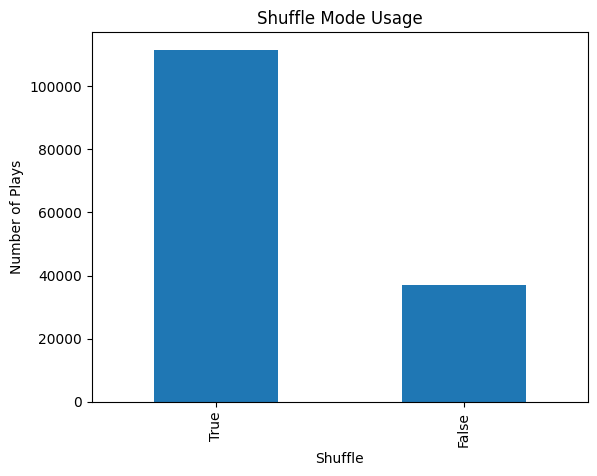

In [ ]:
df["shuffle"].value_counts().plot(kind="bar")

plt.title("Shuffle Mode Usage")
plt.xlabel("Shuffle")
plt.ylabel("Number of Plays")
plt.show()

# top 10 artists

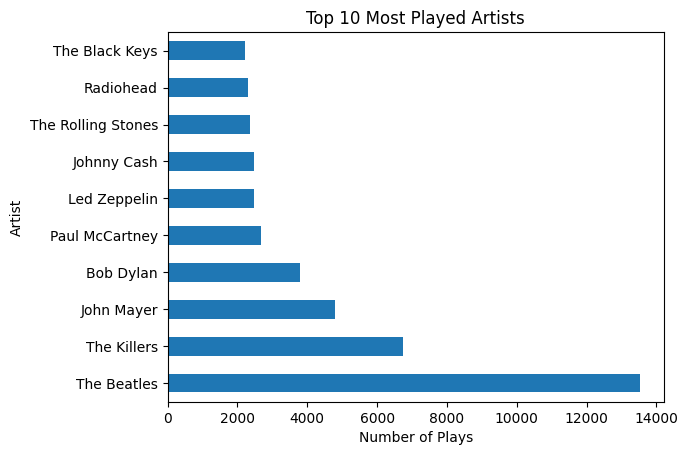

In [ ]:

top_artists = df["artist_name"].value_counts().head(10)

top_artists.plot(kind="barh")

plt.title("Top 10 Most Played Artists")
plt.xlabel("Number of Plays")
plt.ylabel("Artist")
plt.show()

# top 1 tracks

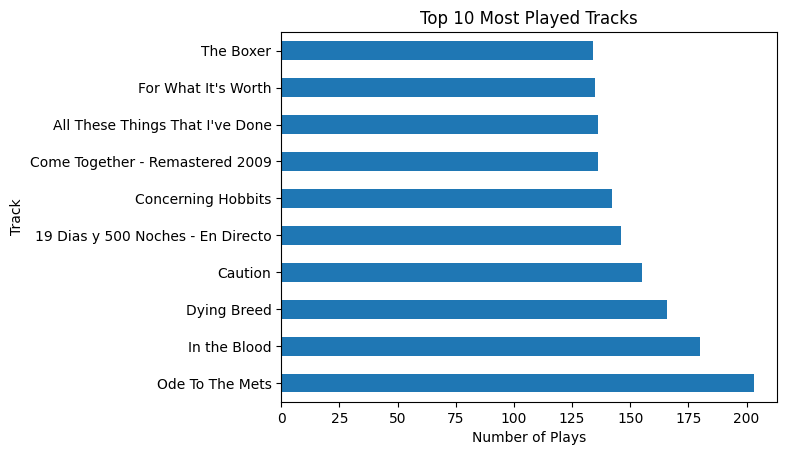

In [ ]:

top_tracks = df["track_name"].value_counts().head(10)

top_tracks.plot(kind="barh")

plt.title("Top 10 Most Played Tracks")
plt.xlabel("Number of Plays")
plt.ylabel("Track")
plt.show()

# converting ts from obj to time

In [ ]:

df["ts"] = pd.to_datetime(df["ts"])

In [ ]:
df["year"] = df["ts"].dt.year
df["month"] = df["ts"].dt.month
df["day"] = df["ts"].dt.day
df["hour"] = df["ts"].dt.hour
df["day_name"] = df["ts"].dt.day_name()

# listening by hour

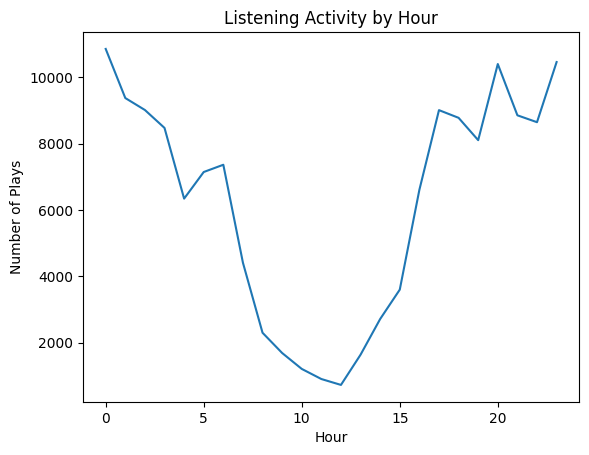

In [ ]:

hourly_listening = df["hour"].value_counts().sort_index()

hourly_listening.plot(kind="line")

plt.title("Listening Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Plays")
plt.show()

# listening by day

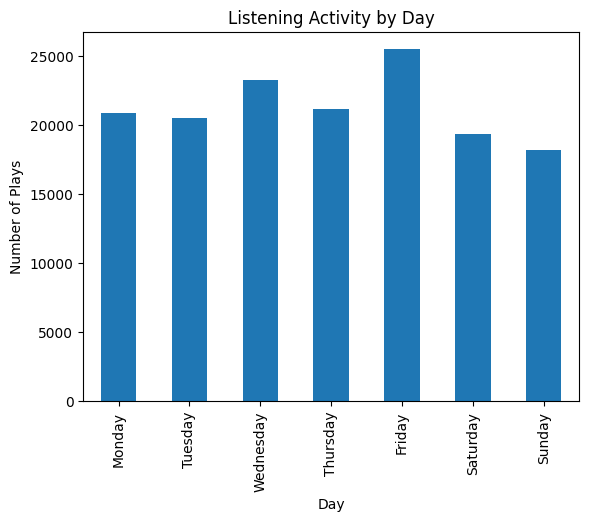

In [ ]:

day_listening = df["day_name"].value_counts()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_listening = day_listening.reindex(day_order)

day_listening.plot(kind="bar")

plt.title("Listening Activity by Day")
plt.xlabel("Day")
plt.ylabel("Number of Plays")
plt.show()

# analyse reason for playback

In [ ]:

df["reason_start"].value_counts()


,count
reason_start,
trackdone,75890
fwdbtn,53686
clickrow,10982
appload,3729
backbtn,2199
playbtn,1441
remote,433
trackerror,120
unknown,23


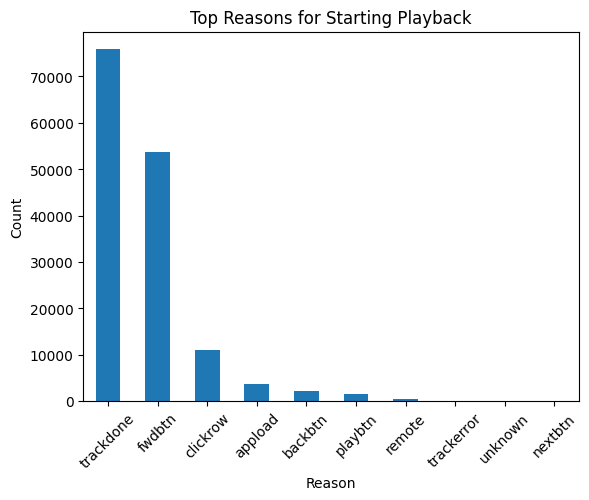

In [ ]:
df["reason_start"].value_counts().head(10).plot(kind="bar")

plt.title("Top Reasons for Starting Playback")
plt.xlabel("Reason")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df["reason_end"].value_counts()

,count
reason_end,
trackdone,76380
fwdbtn,53359
endplay,9872
logout,4364
backbtn,2173
unexpected-exit-while-paused,1724
unknown,268
remote,224
unexpected-exit,118


# correlation heatmap

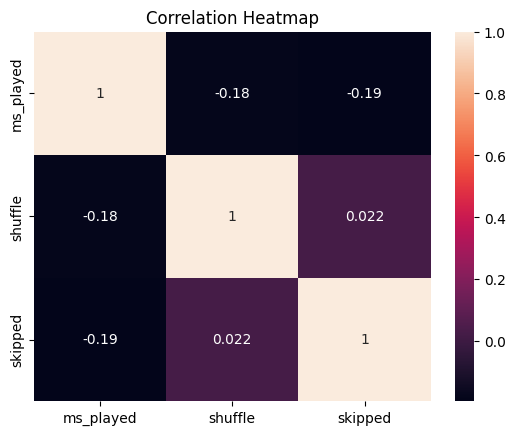

In [ ]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()